In [11]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [1]:
#import required libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# load the dataset 
df = pd.read_csv("knn_regression_dataset.csv")

In [42]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


### Data Preprocessing 

In [43]:
# checking for null values
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [44]:
# check info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [45]:
# check the statistics of the dataset
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


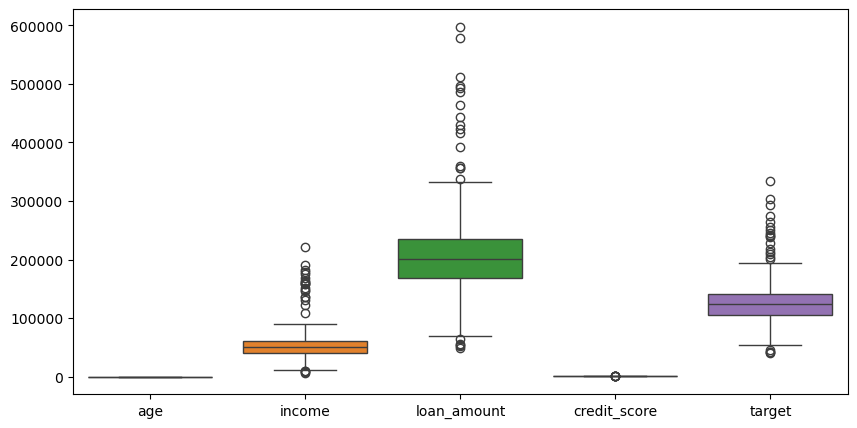

In [46]:
# box plot to check for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()


In [47]:
#handled missing values by filling them with median values
# find the median values of the credit score and income columns and loan amount column
median_credit_score = df['credit_score'].median()
median_income = df['income'].median()
median_loan_amount = df['loan_amount'].median()

# fill the missing values with the median values
df['credit_score'].fillna(median_credit_score, inplace=True)
df['income'].fillna(median_income, inplace=True)
df['loan_amount'].fillna(median_loan_amount, inplace=True)

In [48]:
# handled the outlier length of each column

# credit score column
Q1_credit_score = df['credit_score'].quantile(0.25)
Q3_credit_score = df['credit_score'].quantile(0.75)

IQR_credit_score = Q3_credit_score - Q1_credit_score

lower_bound_credit_score = Q1_credit_score - 1.5 * IQR_credit_score
upper_bound_credit_score = Q3_credit_score + 1.5 * IQR_credit_score

# income column
Q1_income = df['income'].quantile(0.25)
Q3_income = df['income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

# loan amount column
Q1_loan_amount = df['loan_amount'].quantile(0.25)
Q3_loan_amount = df['loan_amount'].quantile(0.75)

IQR_loan_amount = Q3_loan_amount - Q1_loan_amount

lower_bound_loan_amount = Q1_loan_amount - 1.5 * IQR_loan_amount
upper_bound_loan_amount = Q3_loan_amount + 1.5 * IQR_loan_amount




In [49]:
# check the size of outliers in each column
outliers_credit_score = df[(df['credit_score'] < lower_bound_credit_score) | (df['credit_score'] > upper_bound_credit_score)]

outliers_income = df[(df['income'] < lower_bound_income) | (df['income'] > upper_bound_income)]

outliers_loan_amount = df[(df['loan_amount'] < lower_bound_loan_amount) | (df['loan_amount'] > upper_bound_loan_amount)]

print("Number of outliers in credit score column: ", outliers_credit_score.shape[0])
print("Number of outliers in income column: ", outliers_income.shape[0])    
print("Number of outliers in loan amount column: ", outliers_loan_amount.shape[0])

Number of outliers in credit score column:  11
Number of outliers in income column:  25
Number of outliers in loan amount column:  24


In [50]:
# handled outliers by capping function

def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

# cap the outliers in credit score, income and loan amount columns
cap_outlier('credit_score')
cap_outlier('income')
cap_outlier('loan_amount')


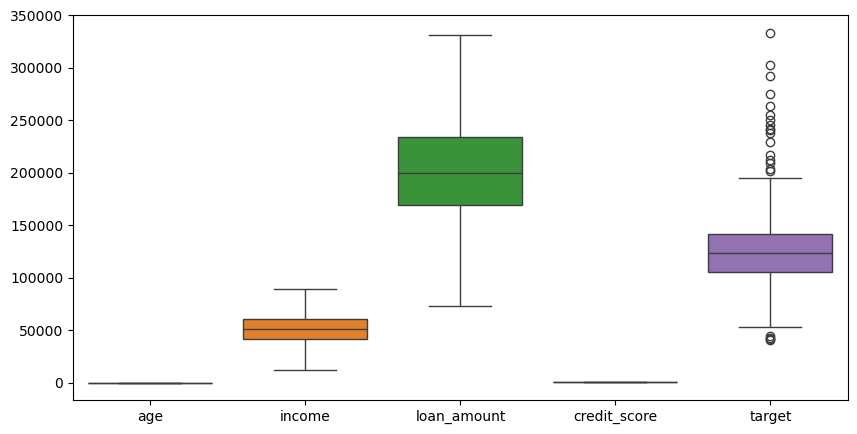

In [51]:
# box plot to check for outliers after capping
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

In [52]:
df.shape

(1000, 7)

In [53]:
# check the city column value counts
df['city'].value_counts()

city
Hyderabad    260
Chennai      259
Bangalore    256
Mumbai       225
Name: count, dtype: int64

In [54]:
# chcek the employment_type  column value counts
df['employment_type'].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [55]:
# handled the categorical variables by one hot encoding

cat = ['city', 'employment_type']
from sklearn.preprocessing import OneHotEncoder 

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[cat])

In [56]:
# encoded_data converted to dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [57]:
# concatenate the encoded dataframe with the original dataframe (excluding the categorical columns)
# drop the cat columns from the original dataframe
df.drop(columns=cat, inplace=True)


In [58]:
df.head()

,age,income,loan_amount,credit_score,target
0,56,25903.305196,286348.192562,789.476075,158793.631698
1,69,53051.954538,180018.190719,596.334039,115596.093965
2,46,38654.738821,211234.236288,611.531000,127231.057638
3,32,28666.194356,246629.541594,710.171152,145102.187078
4,60,40301.406736,129081.713353,622.900855,110623.128404


In [59]:
encoded_df.head()

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [60]:
df =pd.concat([df, encoded_df], axis=1)
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [61]:
# find the skewness of input features
skewness = df.drop(columns=['target']).skew()
skewness


age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [62]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()

print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [63]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['income', 'loan_amount']

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [65]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

#make 2D array 

df['credit_score'] = scaler.fit_transform(df[['credit_score']])

In [68]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,-0.763656,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,-0.545133,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,0.873248,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,-0.381642,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
